## Captstone project

Детекція котиків та собачок на основі датасету [Cats and Dogs Classification Dataset](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)

Детекція побудована на основі нейромереж та інструментарію роботи з нейромережами Tensorflow && Keras.

Побудова детекції відбулась в два етапи:

1. Спершу була спроба побудувати послідовну CNN мережу з нуля - невдало. Ефективність була в районі 48%, що взагалі ні про що.

2. В другому етапі було використано попередньо тренована модель на базі MobileNetV2 - ця спроба була вдалою і вдалося досягти точність 97%.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

import os

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, precision_score, recall_score,
    confusion_matrix
)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/kneu/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1


In [ ]:
import os

pet_path = path + "/PetImages"

input_path = []
label = []

for class_name in os.listdir(pet_path):
    print(path + "/" + class_name)
    for image_path in os.listdir(pet_path + "/" + class_name):
        if class_name == 'Cat':
            label.append(0)
        else:
            label.append(1)
        input_path.append(os.path.join(pet_path, class_name, image_path))

/home/kneu/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1/Cat
/home/kneu/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1/Dog


In [ ]:
df = pd.DataFrame({"images_path": input_path,"label": label})
df['label'] = df['label'].astype('str')
df

,images_path,label
0,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,0
1,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,0
2,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,0
3,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,0
4,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,0
...,...,...
24993,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,1
24994,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,1
24995,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,1
24996,/home/kneu/.cache/kagglehub/datasets/bhavikjik...,1


In [ ]:
l = []
for image in df['images_path']:
    try:
        img = PIL.Image.open(image)
    except:
        l.append(image)

/home/kneu/jupyter/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


## EDA

7932 12499    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
12500    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
12501    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
12502    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
12503    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
                               ...                        
24993    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
24994    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
24995    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
24996    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
24997    /home/kneu/.cache/kagglehub/datasets/bhavikjik...
Name: images_path, Length: 12499, dtype: object


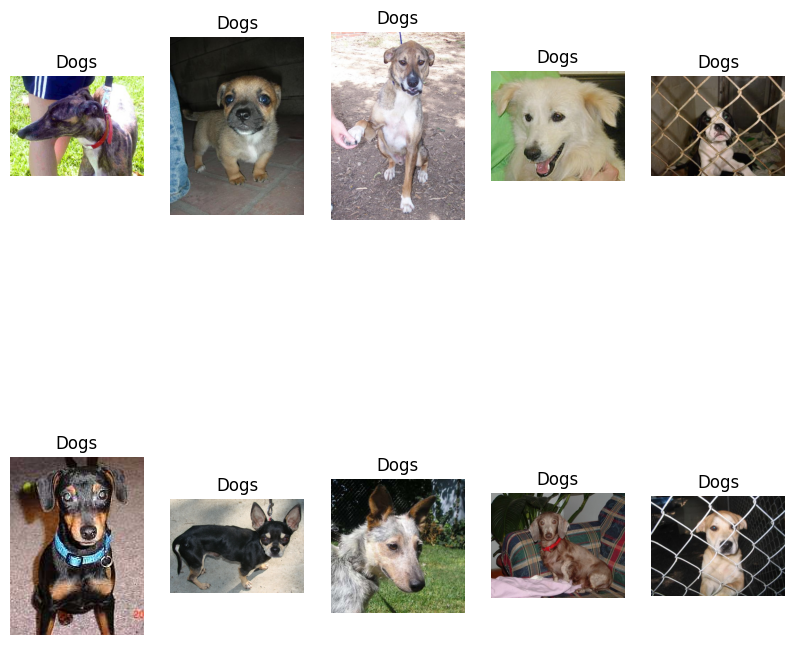

In [ ]:
import random

plt.figure(figsize=(10,10))
temp = df[df['label']=="1"]['images_path']
start = random.randint(0, len(temp))
print(start, temp)
files = temp[start:start+10]

for index, file in enumerate(files):
    plt.subplot(2,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Dogs')
    plt.axis('off')

plt.show()

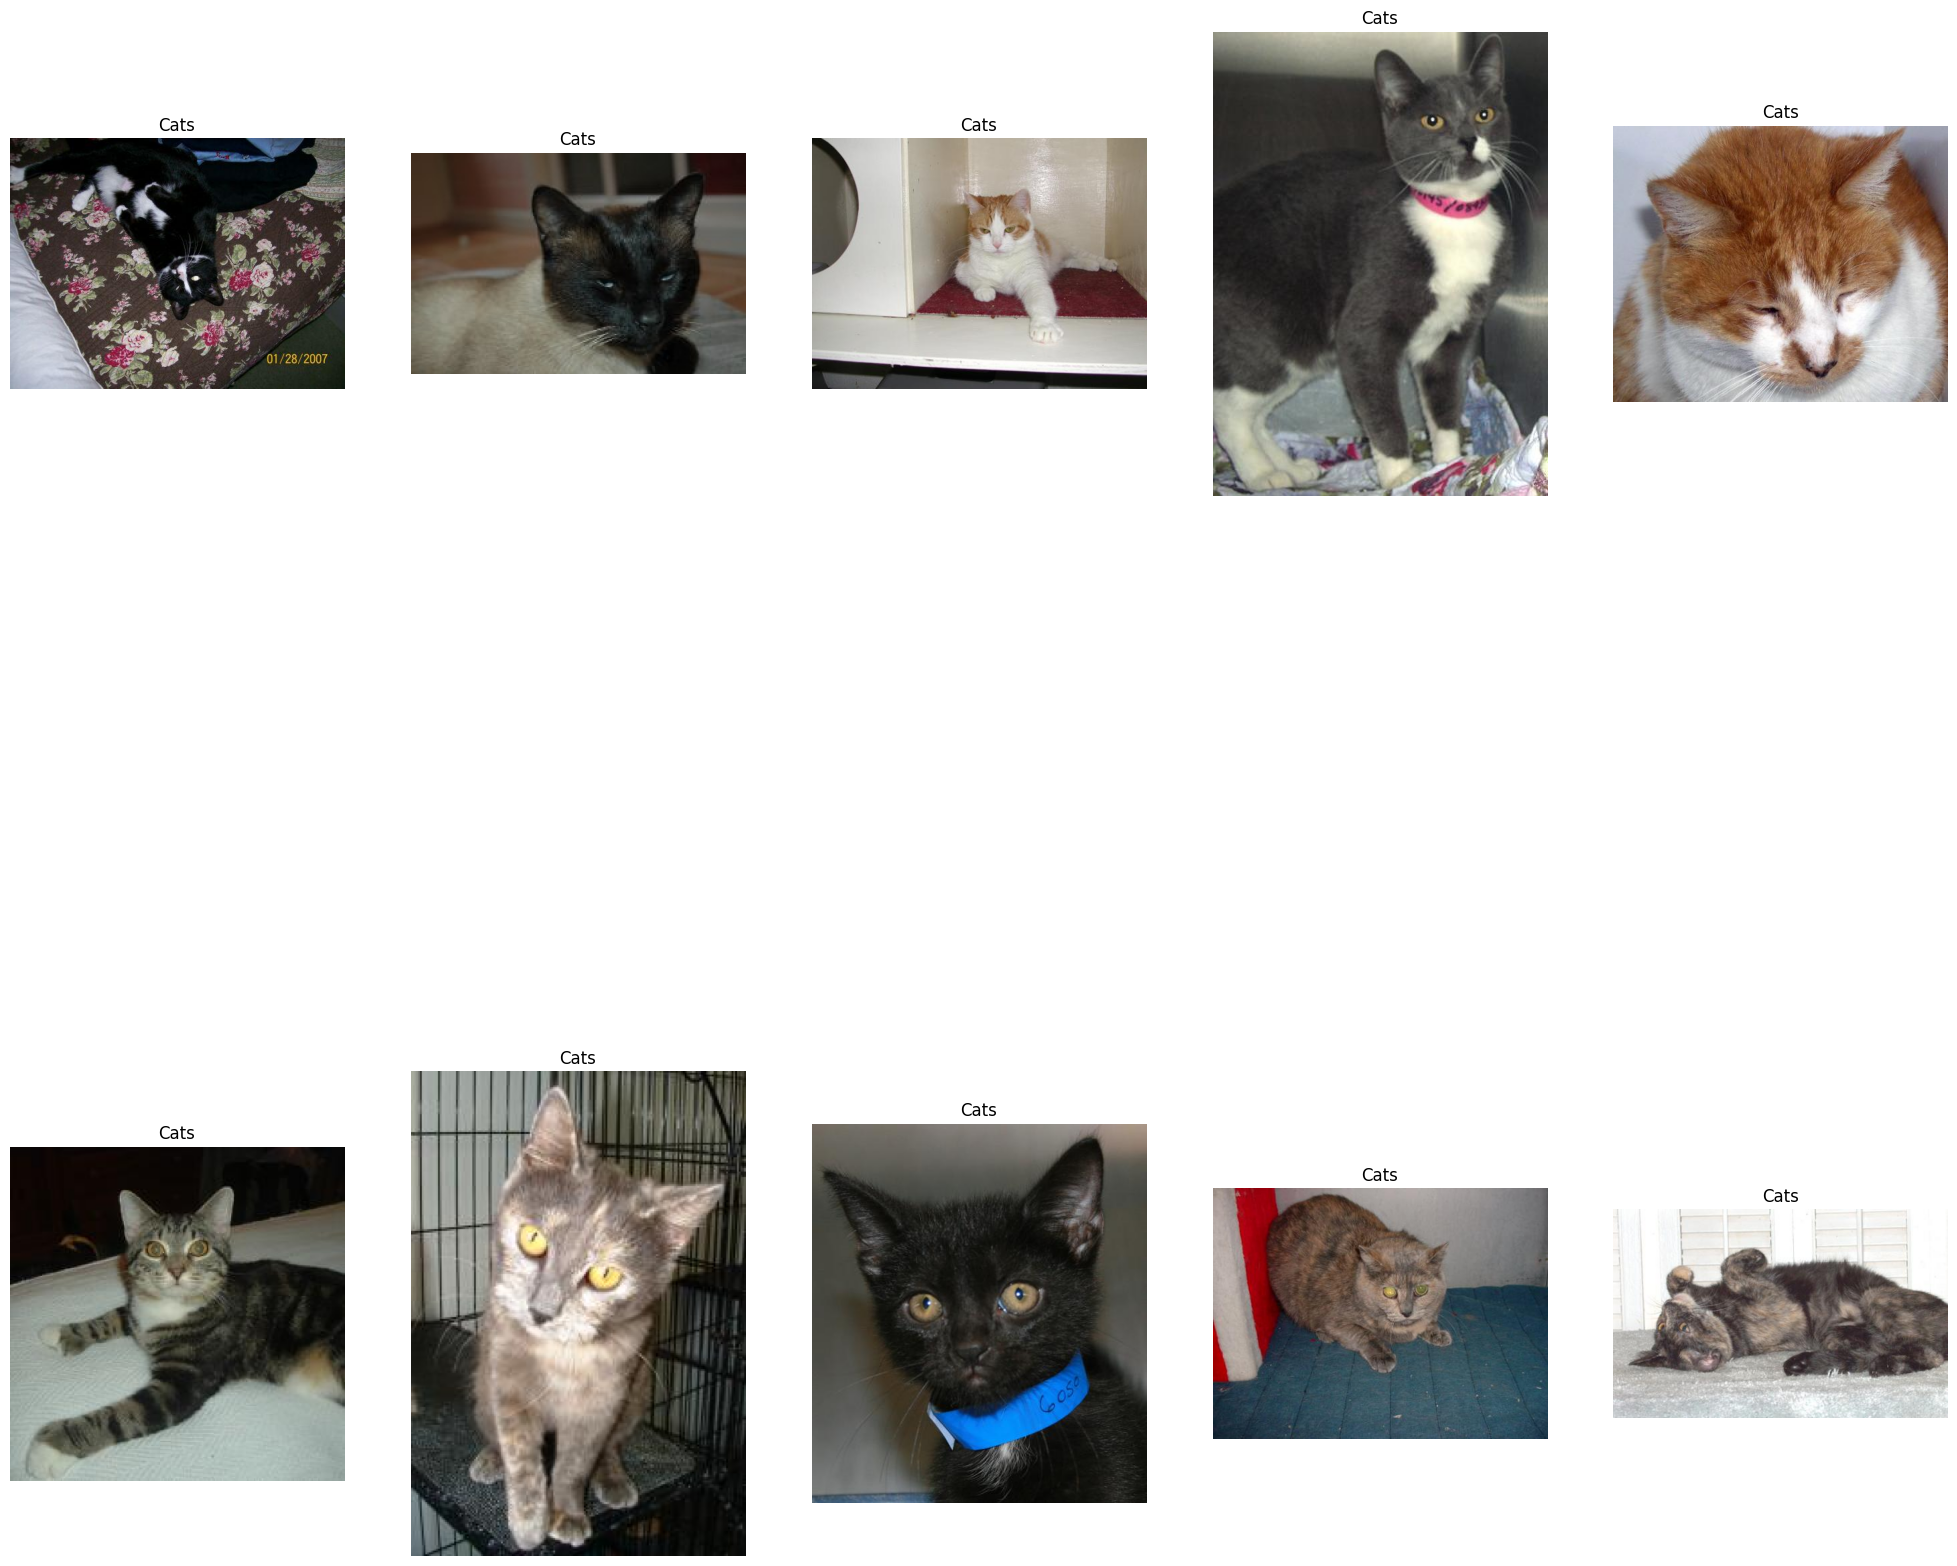

In [ ]:
plt.figure(figsize=(25,25))
temp = df[df['label']=="0"]['images_path']
start = random.randint(0, len(temp))
files = temp[start:start+10]

for index, file in enumerate(files):
    plt.subplot(2,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Cats')
    plt.axis('off')


plt.show()

### Prepare test dataset

In [ ]:
train_val, test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.2, stratify=train_val['label'], random_state=42)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    train,
    x_col='images_path',
    y_col='label',
    target_size=(128, 128),
    class_mode='binary',
    batch_size=32,
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    val,
    x_col='images_path',
    y_col='label',
    target_size=(128, 128),
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    test,
    x_col='images_path',
    y_col='label',
    target_size=(128, 128),
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

Found 15998 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


## Make CNN

# Building from scratch

(in result in doesn't show good accuracy - less then 50%)

In [ ]:
# model = Sequential()

# model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)))
# model.add(MaxPooling2D(2,2))

# model.add(Conv2D(64, (3,3), activation='relu'))
# model.add(MaxPooling2D(2,2))

# model.add(Conv2D(128, (3,3), activation='relu'))
# model.add(MaxPooling2D(2,2))

# model.add(Conv2D(128, (3,3), activation='relu'))
# model.add(MaxPooling2D(2,2))

# model.add(Flatten())
#model.add(Dense(512, activation='relu'))
#model.add(Dense(1, activation='sigmoid'))

# Use pretrained model

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

2025-05-26 15:39:14.634871: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/home/kneu/jupyter/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
193/500 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.9262 - loss: 0.1983

/home/kneu/jupyter/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 189ms/step - accuracy: 0.9413 - loss: 0.1642 - val_accuracy: 0.9513 - val_loss: 0.1105 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 93s 185ms/step - accuracy: 0.9672 - loss: 0.0861 - val_accuracy: 0.9715 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 184ms/step - accuracy: 0.9728 - loss: 0.0711 - val_accuracy: 0.9650 - val_loss: 0.0884 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.9778 - loss: 0.0599 - val_accuracy: 0.9670 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.9795 - loss: 0.0529 - val_accuracy: 0.9682 - val_loss: 0.0761 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 183ms/step - accuracy: 0.9832 - loss: 0.0456 - val_accuracy: 0.9670 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.9850 - los

In [ ]:
model.save('cats_dogs_classifier.keras')

## Results

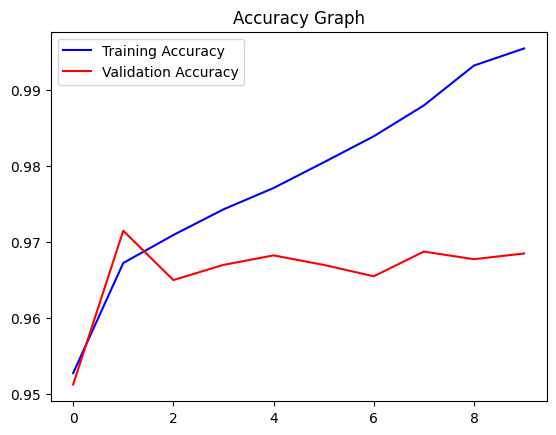

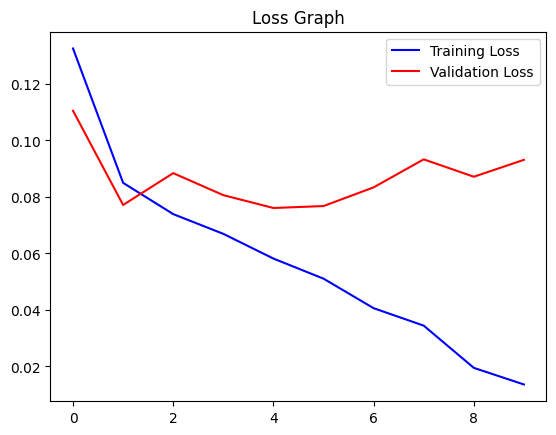

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [ ]:
y_true = test_generator.classes

In [ ]:
y_pred_probs = model.predict(test_generator)

/home/kneu/jupyter/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step


In [ ]:
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


In [ ]:
# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

# Aggregate metrics into a dictionary
metrics = {
    'accuracy': accuracy,
    'balanced_accuracy': balanced_acc,
    'f1_score': f1,
    'precision': precision,
    'recall': recall,
    'roc_auc': roc_auc,
    'confusion_matrix': cm
}

In [ ]:
# Display the metrics
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value}")

accuracy: 0.9714
balanced_accuracy: 0.9714
f1_score: 0.9714969105042854
precision: 0.9682161303138657
recall: 0.9748
roc_auc: 0.9714
confusion_matrix: [[2420   80]
 [  63 2437]]


## Висновки

Було побудовано нейромережу для детекції котиків та собак.

Використання попередньо натренованої моделі пришвидшує тренування моделі майже в вдвічі. Також, скоротити час генерації та збільшити точність дозволяють callback-компоненти EarlyStopping ти ReduceLROnPlateau (зупиняють тренування, коли метрика точності буде знижуватися).

Точність мережі складає 97%.

Або на 100 собак - знайдеться три кішки 🐱🐶 🐈‍⬛  🐈

․°𓃠•°․𓃦․•